## `Training a small word2vec model`

In [1]:
from gensim.models import Word2Vec

sentences = [
    ["i","love","nlp"],
    ["nlp","is","interesting"],
    ["machine","learning","is","powerful"]
]

model = Word2Vec(sentences,
                 vector_size=50,
                 window=2,
                 min_count=1)

print(model.wv["nlp"])


[-0.01631583  0.0089916  -0.00827415  0.00164907  0.01699724 -0.00892435
  0.009035   -0.01357392 -0.00709698  0.01879702 -0.00315531  0.00064274
 -0.00828126 -0.01536538 -0.00301602  0.00493959 -0.00177605  0.01106732
 -0.00548595  0.00452013  0.01091159  0.01669191 -0.00290748 -0.01841629
  0.0087411   0.00114357  0.01488382 -0.00162657 -0.00527683 -0.01750602
 -0.00171311  0.00565313  0.01080286  0.01410531 -0.01140624  0.00371764
  0.01217773 -0.0095961  -0.00621452  0.01359526  0.00326295  0.00037983
  0.00694727  0.00043555  0.01923765  0.01012121 -0.01783478 -0.01408312
  0.00180291  0.01278507]


In [2]:
# Similar words
print(model.wv.most_similar("nlp"))

[('machine', 0.12486252933740616), ('love', 0.07399575412273407), ('is', 0.04237302392721176), ('interesting', 0.01827714592218399), ('powerful', 0.011071967892348766), ('learning', -0.17424817383289337), ('i', -0.1754782646894455)]


In [13]:
# Word similarity score
print(model.wv.similarity("machine", "learning"))

-0.20600516


## `Training a small GloVe model`

In [5]:
import gensim.downloader as api

# Load pre-trained GloVe vectors (downloads ~66MB on first run)
glove = api.load("glove-wiki-gigaword-50")

print(glove["nlp"])

[==================================================] 100.0% 66.0/66.0MB downloaded
[-0.6721    -0.17858    0.20188    0.63581   -0.31304    1.2183
 -0.13314   -1.1776    -0.27009    0.52236   -0.0086308 -0.056211
  1.3483    -1.0131    -1.0985    -0.24086   -0.0066808 -0.14822
 -0.044672   0.54472   -0.92966   -0.69065    0.91675    0.054691
 -0.2081     1.1201     0.92071   -1.2295     0.107      0.65846
 -0.84775   -0.14577   -0.69941    0.83514    0.90995   -0.70647
 -0.78513    0.82611    1.0785     0.29806    1.0306     0.19589
 -0.5562     0.43684    0.5979     0.77427    0.40238    0.57069
  0.29321    1.0723   ]


In [6]:
# Similar words
print(glove.most_similar("nlp"))

[('hagelin', 0.7022941708564758), ('.760', 0.691605269908905), ('inp', 0.683588981628418), ('+18', 0.6736968159675598), ('clarithromycin', 0.6701129674911499), ('+11', 0.6613443493843079), ('+16', 0.6602961421012878), ('5:2', 0.6571424007415771), ('+14', 0.650152325630188), ('tretinoin', 0.6494036912918091)]


In [7]:
# Word similarity score
print(glove.similarity("machine", "learning"))

0.4802689


## `Training a small FastText model`

In [8]:
from gensim.models import FastText

sentences = [
    ["i","love","nlp"],
    ["nlp","is","interesting"],
    ["machine","learning","is","powerful"]
]

ft_model = FastText(sentences,
                    vector_size=50,
                    window=2,
                    min_count=1)

print(ft_model.wv["nlp"])

[-0.00026606  0.00326783 -0.00094617 -0.0044982   0.00477384 -0.00081736
  0.00637789 -0.00240626 -0.0002019  -0.00248004  0.00193845  0.00938364
 -0.00214584  0.00384359 -0.00245775  0.0034873  -0.00125352  0.00155698
 -0.00344352 -0.00159109  0.00225761 -0.00030928 -0.00678895 -0.00303331
 -0.00727789 -0.0011783   0.0018157  -0.00079077  0.004036   -0.00702453
  0.00587029 -0.00356096  0.00367655 -0.00412466 -0.00925159  0.00272273
 -0.00579035 -0.00506509 -0.00179403 -0.00167013  0.00332182  0.00507272
 -0.00269846 -0.00031076  0.00164627 -0.00074434 -0.00212768 -0.00064864
  0.00104991  0.00170162]


In [9]:
# Similar words
print(ft_model.wv.most_similar("nlp"))

[('love', 0.04952973872423172), ('powerful', 0.03523439168930054), ('is', 0.03151905909180641), ('i', -0.10272710025310516), ('learning', -0.14026384055614471), ('machine', -0.22233521938323975), ('interesting', -0.23534952104091644)]


In [10]:
# Word similarity score
print(ft_model.wv.similarity("machine", "learning"))

-0.14381303


## `Visualizing word embeddings in two dimensions`

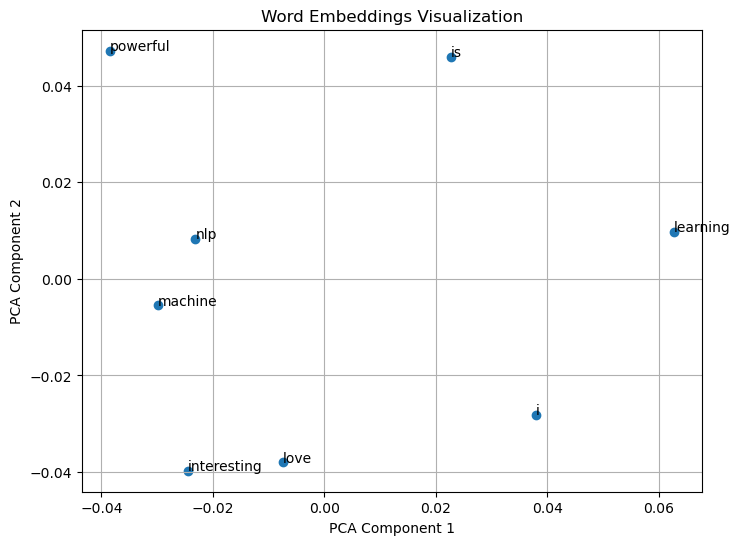

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.decomposition import PCA
import numpy as np

# Get word vectors for visualization
words = ["i", "love", "nlp", "is", "interesting", "machine", "learning", "powerful"]
word_vectors = np.array([model.wv[word] for word in words])

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)   
reduced_vectors = pca.fit_transform(word_vectors)

# Plot the words in 2D space
plt.figure(figsize=(8, 6))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]))
plt.title("Word Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()
